<a href="https://colab.research.google.com/github/VictorGMSS/Classifica-o_multiclasse/blob/main/classificacao_multiclasse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <font color='SteelBlue'>Importando Bibliotecas</h1>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

## <font color='SteelBlue'>Conhecendo os dados</h1>

### Carregando os dados

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/VictorGMSS/Classifica-o_multiclasse/refs/heads/main/dados_estudantes.csv')

In [ ]:
df.head()

,Estado civil,Migração,Sexo,Idade na matrícula,Estrangeiro,Necessidades educacionais especiais,Devedor,Taxas de matrícula em dia,Bolsista,Taxa de desemprego,...,disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),disciplinas 2º semestre (creditadas),disciplinas 2º semestre (matriculadas),disciplinas 2º semestre (avaliações),disciplinas 2º semestre (aprovadas),disciplinas 2º semestre (notas),disciplinas 2º semestre (sem avaliações),Target
0,Solteiro,Sim,Masculino,20,Não,Não,Não,Sim,Não,10.8,...,0,0.000000,0,0,0,0,0,0.000000,0,Desistente
1,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,13.9,...,6,14.000000,0,0,6,6,6,13.666667,0,Graduado
2,Solteiro,Sim,Masculino,19,Não,Não,Não,Não,Não,10.8,...,0,0.000000,0,0,6,0,0,0.000000,0,Desistente
3,Solteiro,Sim,Feminino,20,Não,Não,Não,Sim,Não,9.4,...,6,13.428571,0,0,6,10,5,12.400000,0,Graduado
4,Casado,Não,Feminino,45,Não,Não,Não,Sim,Não,13.9,...,5,12.333333,0,0,6,6,6,13.000000,0,Graduado


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Estado civil                              4424 non-null   object 
 1   Migração                                  4424 non-null   object 
 2   Sexo                                      4424 non-null   object 
 3   Idade na matrícula                        4424 non-null   int64  
 4   Estrangeiro                               4424 non-null   object 
 5   Necessidades educacionais especiais       4424 non-null   object 
 6   Devedor                                   4424 non-null   object 
 7   Taxas de matrícula em dia                 4424 non-null   object 
 8   Bolsista                                  4424 non-null   object 
 9   Taxa de desemprego                        4424 non-null   float64
 10  Taxa de inflação                    

### Entendendo os dados

In [ ]:
df['Target'].unique()

array(['Desistente', 'Graduado', 'Matriculado'], dtype=object)

## <font color='SteelBlue'>Explorando os dados</h1>

### Dados demográficos


*   Estado civil
*   Migração
*   Sexo
*   Idade na inscrição
*   Estrangeiro

In [ ]:
df['Estado civil'].value_counts(normalize=True)*100

,proportion
Estado civil,
Solteiro,88.584991
Casado,8.566908
Divorciado,2.056962
União Estável,0.565099
Legalmente Separado,0.135624
Viúvo,0.090416


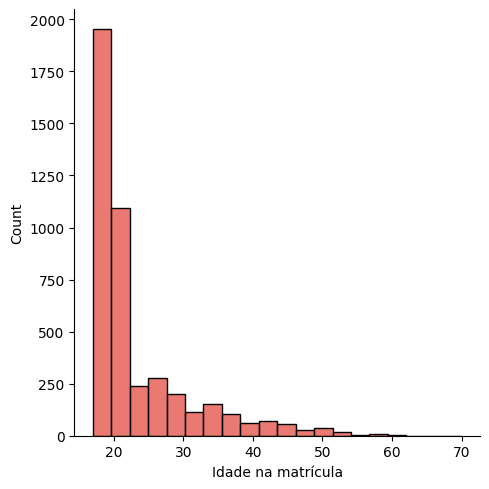

In [ ]:
sns.displot(df['Idade na matrícula'], bins=20)

In [ ]:
color_dict = {'Desistente': '#e34c42','Graduado': '#4dc471', 'Matriculado': '#3b71db'}

# Definindo a paleta de cores
sns.set_palette(list(color_dict.values()))

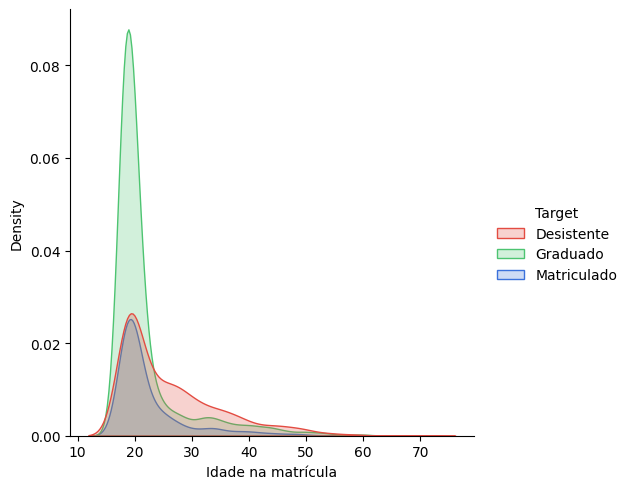

In [ ]:
sns.displot(data=df, x='Idade na matrícula', hue='Target', kind='kde', fill=True)
plt.show()

In [ ]:
df['Estrangeiro'].value_counts(normalize=True)*100

,proportion
Estrangeiro,
Não,97.513562
Sim,2.486438


In [ ]:
df['Sexo'].value_counts(normalize=True)*100

,proportion
Sexo,
Feminino,64.82821
Masculino,35.17179


<Axes: xlabel='Sexo', ylabel='count'>

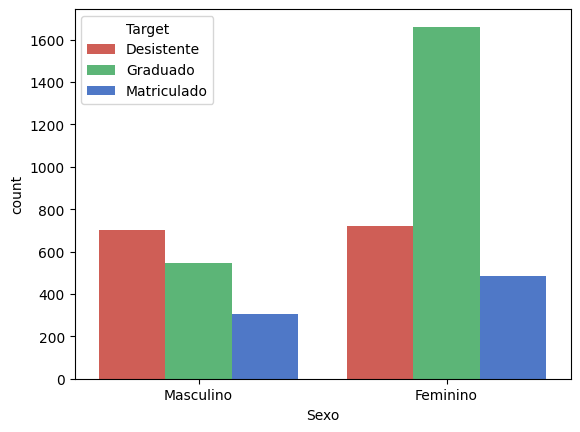

In [ ]:
sns.countplot(x='Sexo', hue='Target', data=df)

### Dados socioeconômicos e macroeconômicos

**Socioeconômicos**

*   Necessidades educacionais especiais
*   Devedor
*   Taxas de matrícula em dia
*   Bolsista

**Macroeconômicos**

*   Taxa de desemprego
*   Taxa de inflação
*   PIB


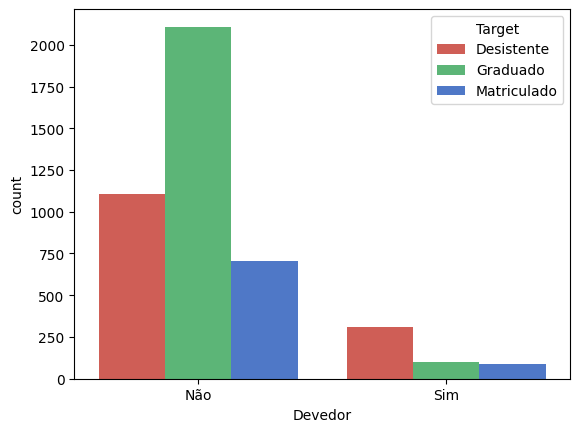

In [ ]:
sns.countplot(x='Devedor', hue='Target', data=df)
plt.show()

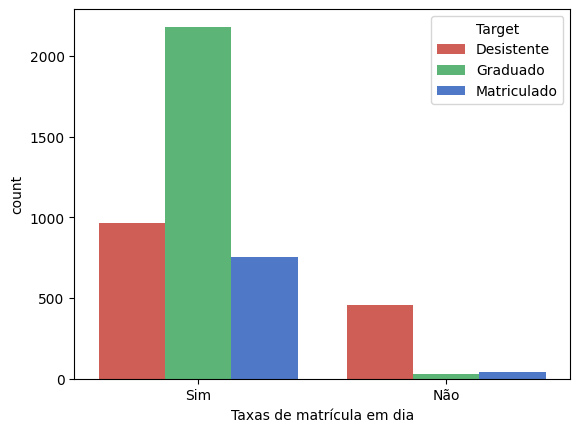

In [ ]:
sns.countplot(x='Taxas de matrícula em dia', hue='Target', data=df)
plt.show()

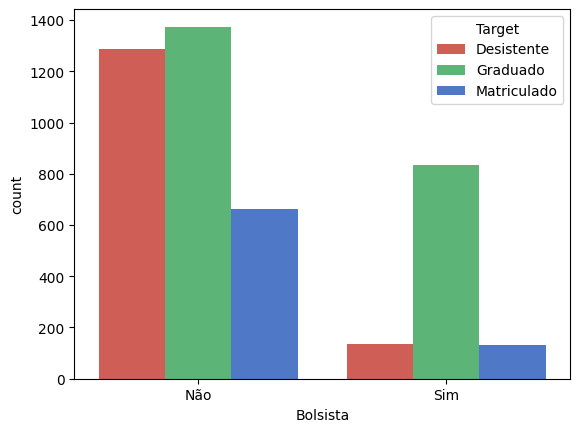

In [ ]:
sns.countplot(x='Bolsista', hue='Target', data=df)
plt.show()

### Dados no momento da matrícula

*   Curso
*   Período
*   Qualificação prévia

In [ ]:
contagem = df.groupby(['Curso', 'Target']).size().reset_index(name='Contagem')

contagem['Porcentagem'] = contagem.groupby('Curso')['Contagem'].transform(lambda x: (x/x.sum())*100)

fig = px.bar(contagem, y='Curso', x='Porcentagem', color='Target', orientation='h', color_discrete_map = color_dict)

fig.show()

### Dados acadêmicos

*   disciplinas creditadas
*   disciplinas matriculadas
*   disciplinas avaliações
*   disciplinas aprovadas
*   disciplinas notas
*   disciplinas sem avaliações
*   disciplinas faltas

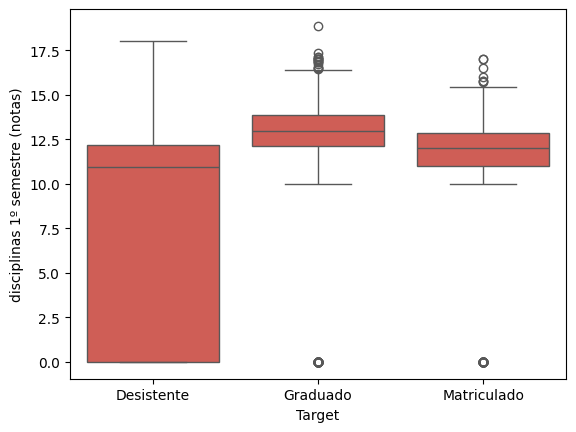

In [ ]:
sns.boxplot(x='Target', y='disciplinas 1º semestre (notas)', data=df)
plt.show()

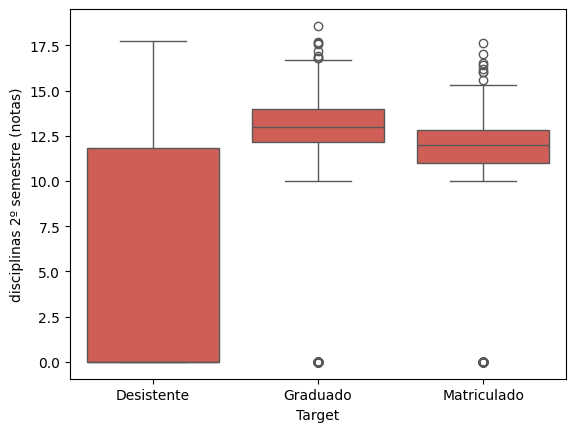

In [ ]:
sns.boxplot(x='Target', y='disciplinas 2º semestre (notas)', data=df)
plt.show()

In [ ]:
df['Target'].value_counts(normalize=True)*100

,proportion
Target,
Graduado,49.932188
Desistente,32.120253
Matriculado,17.947559


## <font color='SteelBlue'>Realizando o treinamento</h1>

### Preparando os dados

In [ ]:
colunas_categoricas = ['Migração', 'Sexo','Estrangeiro', 'Necessidades educacionais especiais', 'Devedor',
                     'Taxas de matrícula em dia', 'Bolsista', 'Período','Estado civil', 'Curso', 'Qualificação prévia']

In [ ]:
encoder = OneHotEncoder(drop='if_binary')

df_categorico = df[colunas_categoricas]

df_encoded = pd.DataFrame(encoder.fit_transform(df_categorico).toarray(),
                          columns=encoder.get_feature_names_out(colunas_categoricas))

df_final = pd.concat([df.drop(colunas_categoricas, axis = 1), df_encoded], axis=1)


In [ ]:
df_final

,Idade na matrícula,Taxa de desemprego,Taxa de inflação,PIB,disciplinas 1º semestre (creditadas),disciplinas 1º semestre (matriculadas),disciplinas 1º semestre (avaliações),disciplinas 1º semestre (aprovadas),disciplinas 1º semestre (notas),disciplinas 1º semestre (sem avaliações),...,Qualificação prévia_Educação básica 3º ciclo (9º/10º/11º ano) ou equivalente,Qualificação prévia_Educação secundária,Qualificação prévia_Educação superior - bacharelado,Qualificação prévia_Educação superior - doutorado,Qualificação prévia_Educação superior - licenciatura,Qualificação prévia_Educação superior - licenciatura (1º ciclo),Qualificação prévia_Educação superior - mestrado,Qualificação prévia_Educação superior - mestrado (2º ciclo),Qualificação prévia_Frequência de educação superior,Qualificação prévia_Outro - 11º ano de escolaridade
0,20,10.8,1.4,1.74,0,0,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,19,13.9,-0.3,0.79,0,6,6,6,14.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,19,10.8,1.4,1.74,0,6,0,0,0.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,9.4,-0.8,-3.12,0,6,8,6,13.428571,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,45,13.9,-0.3,0.79,0,6,9,5,12.333333,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,19,15.5,2.8,-4.06,0,6,7,5,13.600000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4420,18,11.1,0.6,2.02,0,6,6,6,12.000000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4421,30,13.9,-0.3,0.79,0,7,8,7,14.912500,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4422,20,9.4,-0.8,-3.12,0,5,5,5,13.800000,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 65 columns):
 #   Column                                                                        Non-Null Count  Dtype  
---  ------                                                                        --------------  -----  
 0   Idade na matrícula                                                            4424 non-null   int64  
 1   Taxa de desemprego                                                            4424 non-null   float64
 2   Taxa de inflação                                                              4424 non-null   float64
 3   PIB                                                                           4424 non-null   float64
 4   disciplinas 1º semestre (creditadas)                                          4424 non-null   int64  
 5   disciplinas 1º semestre (matriculadas)                                        4424 non-null   int64  
 6   disciplinas 1º semestre (avaliaç

### Separando os dados

In [ ]:
x = df_final.drop('Target', axis=1)
y = df_final['Target']

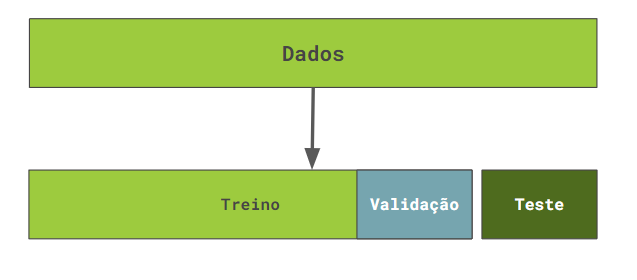

In [ ]:
x, x_teste, y, y_teste = train_test_split(x, y, test_size = 0.15, stratify = y, random_state = 0)
x_treino, x_val, y_treino, y_val = train_test_split(x, y, stratify=y, random_state=0)

### Treinando o modelo com Random Forest Classifier

In [ ]:
modelo_rf = RandomForestClassifier(random_state=0)
modelo_rf.fit(x_treino, y_treino)
y_pred = modelo_rf.predict(x_val)
print(f'Acurácia de treino: {modelo_rf.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(x_val, y_val)}')

Acurácia de treino: 0.9975177304964539
Acurácia de validação: 0.7680851063829788


In [ ]:
modelo_rf = RandomForestClassifier(random_state=0, max_depth=10)
modelo_rf.fit(x_treino, y_treino)
y_pred = modelo_rf.predict(x_val)
print(f'Acurácia de treino: {modelo_rf.score(x_treino, y_treino)}')
print(f'Acurácia de validação: {modelo_rf.score(x_val, y_val)}')

Acurácia de treino: 0.898936170212766
Acurácia de validação: 0.7734042553191489


## <font color='SteelBlue'>Avaliando o modelo</h1>

### Analisando a matriz de confusão

In [ ]:
matriz_confusao = confusion_matrix(y_val, y_pred)
matriz_confusao

array([[232,  52,  18],
       [  8, 451,  10],
       [ 44,  81,  44]])

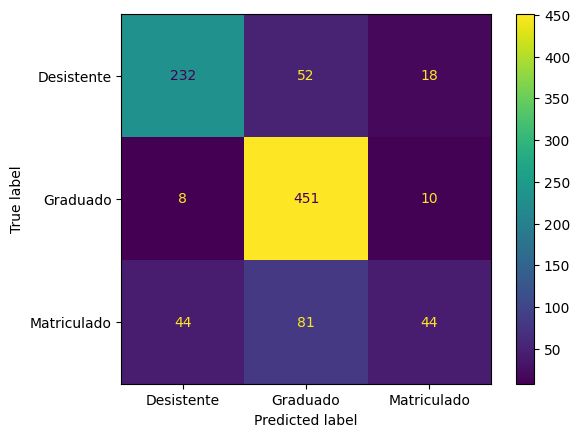

In [ ]:
visualizacao = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=modelo_rf.classes_)
visualizacao.plot()
plt.show()

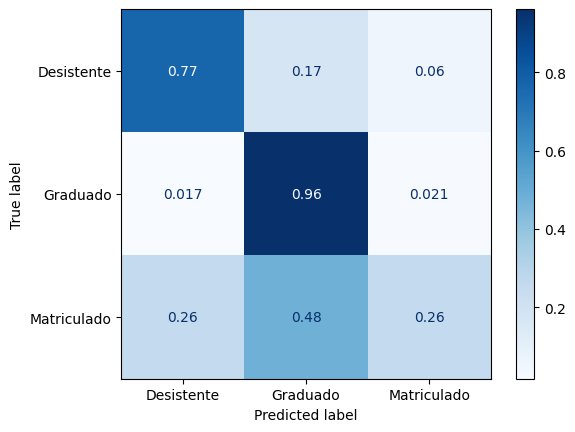

(None,)

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues')
plt.show(),

### Analisando o relatório de métricas

In [ ]:
report = classification_report(y_val, y_pred)
print('Relatório de Classificação:\n', report)

Relatório de Classificação:
               precision    recall  f1-score   support

  Desistente       0.82      0.77      0.79       302
    Graduado       0.77      0.96      0.86       469
 Matriculado       0.61      0.26      0.37       169

    accuracy                           0.77       940
   macro avg       0.73      0.66      0.67       940
weighted avg       0.76      0.77      0.75       940



### Aplicando a técnica de superamostragem

In [ ]:
oversample = SMOTE(random_state=0)
x_balanceado, y_balanceado = oversample.fit_resample(x_treino, y_treino)

In [ ]:
y_balanceado.value_counts()

,count
Target,
Desistente,1408
Graduado,1408
Matriculado,1408


In [ ]:
modelo = RandomForestClassifier(random_state=0, max_depth=10)
modelo.fit(x_balanceado, y_balanceado)
y_pred = modelo.predict(x_val)

### Analisando as métricas após o balanceamento

              precision    recall  f1-score   support

  Desistente       0.85      0.72      0.78       302
    Graduado       0.81      0.87      0.84       469
 Matriculado       0.48      0.52      0.50       169

    accuracy                           0.76       940
   macro avg       0.72      0.70      0.71       940
weighted avg       0.77      0.76      0.76       940



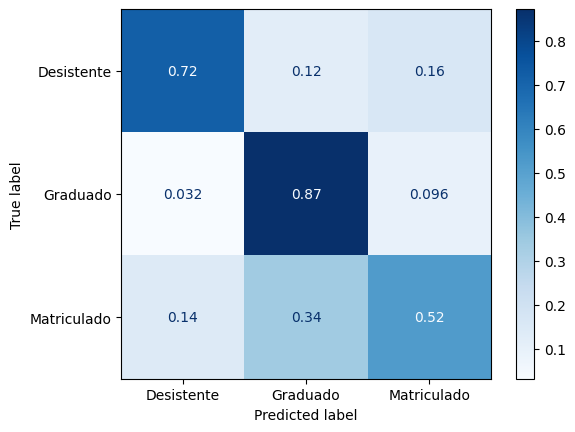

In [ ]:
print(classification_report(y_val, y_pred))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, normalize='true', cmap='Blues')
plt.show()

## <font color='SteelBlue'>Validando o modelo</h1>

### Pipeline para validação

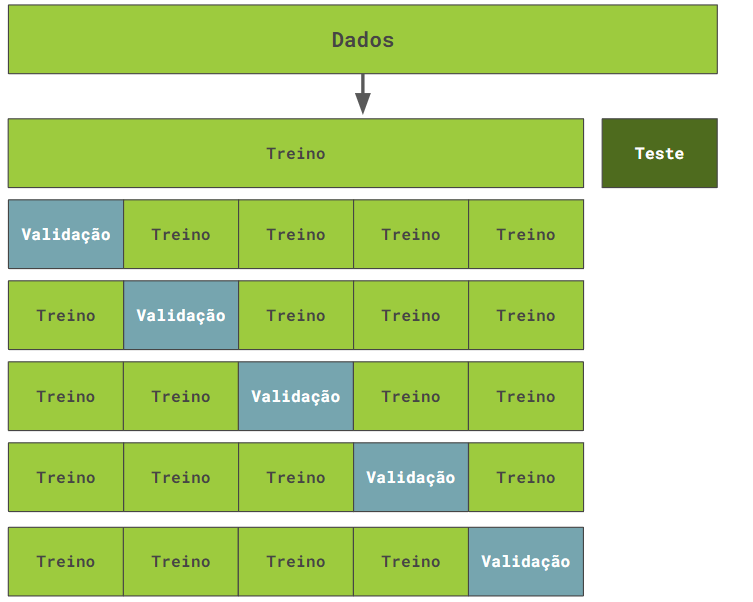

In [ ]:
modelo = RandomForestClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()), ('floresta', modelo)])

In [ ]:
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 0)
cv_resultados = cross_validate(pipeline, x, y, cv = skf, scoring = 'recall_weighted')
cv_resultados['test_score']

array([0.76595745, 0.73404255, 0.7393617 , 0.76994681, 0.75664894])

In [ ]:
media = cv_resultados['test_score'].mean()
desvio_padrao = cv_resultados['test_score'].std()
print(f'Intervalo de confiança: [{media-2*desvio_padrao}, {min(media+2*desvio_padrao, 1.0)}]')

Intervalo de confiança: [0.7247154067780338, 0.7816675719453706]


### Testando o modelo

              precision    recall  f1-score   support

  Desistente       0.85      0.70      0.76       181
    Graduado       0.80      0.85      0.82       282
 Matriculado       0.46      0.52      0.49       101

    accuracy                           0.74       564
   macro avg       0.70      0.69      0.69       564
weighted avg       0.75      0.74      0.74       564



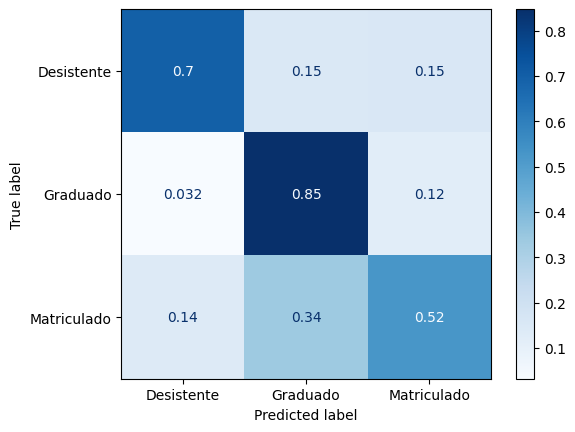

In [ ]:
oversample = SMOTE()
x_balanceado, y_balanceado = oversample.fit_resample(x, y)
modelo = RandomForestClassifier(random_state = 0, max_depth = 10)
modelo.fit(x_balanceado, y_balanceado)
y_pred = modelo.predict(x_teste)

print(classification_report(y_teste, y_pred))
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, normalize='true', cmap='Blues');